### Requirements
jupyter==1.1.1<br>
matplotlib==3.10.8<br>
numpy==2.4.2<br>
scipy==1.17.0<br>
ipywidgets==8.1.8


## Pre-Lab Question Answers:

### Question 1: What technique is used to capture the relatively high frequency movement of the folds? Explain its principle of operation.

Videostroboscopy is a common method used to capture the high frequncy motion of vocal folds. The tool is able to capture slow motion vibrartions of the vocal folds. First, using a microphone, the natural frequency of the voice is measured. Then the images of the vocal folds are sampled at a frequency slightly lower than the natural frequency of the voice. By doing so, it is possible to distinctively capture the phases of the vibration of the vocal fold. The natural frequency of the voice is a baseline at which the folds are vibrating. By sampling at a rate lesser than this frequency, we effectively capture a sparse series of images for the slow-motion vibration. [1]

### Question 2: Can you find evidence for this phase difference in the film linked in the previous section
Yes, if the video: https://www.youtube.com/watch?v=9Tlpkdq8a8c is watched at a slower speed it is clear that the folds behind leads the folds up in the front. It is a bit challenging to take an image to do it. The next mark down cell shows the phase difference for closing folds. As the diagram shows, the folds behind are ahead of the forward folds in the closing stage.


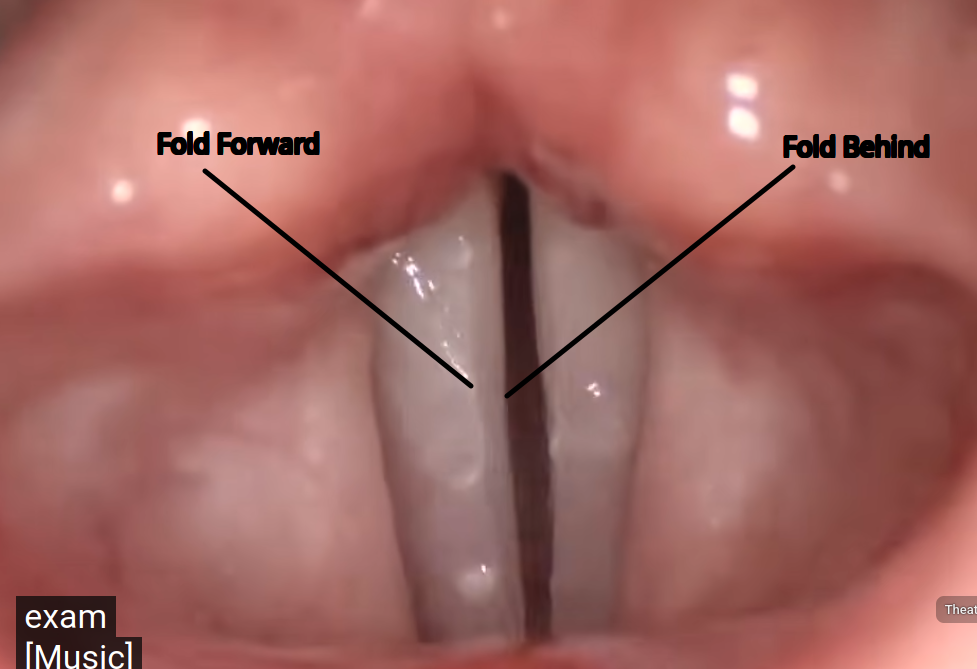

### Question 3: Derivation for small time differences $\tau$

$$x_1 = x_{01} + f(t+\tau) \quad \text{and}\quad x_2 = x_{02}+f(t-\tau) \quad \text{and} \quad \epsilon = \frac{1}{2}\left(\left(x_1-x_{01}\right)+\left(x_2-x_{02}\right)
\right)$$

Using the equations for $x_1$ and $x_2$, $\epsilon$ can be written as a function in $f$

$$\epsilon = x\left(z=\frac{T}{2},t\right)$$

Next, use the small time difference approximation: $f(t+\tau)=f(t)+\tau \frac{df}{dt}$

$$\epsilon = f(t), \quad x_1 = x_{01} + f(t)+\tau \frac{df}{dt},\quad x_2 = x_{02} + f(t)-\tau \frac{df}{dt}$$

Using $\epsilon = f(t)$ and $\dot{\epsilon}=\frac{df}{dt}$

$$x_1 = x_{01}+\epsilon+\tau \dot{\epsilon}, \quad x_2 = x_{02}+\epsilon-\tau \dot{\epsilon}$$

The respective areas are $a_i = 2Wx_i$

Therefore

$$a_1 = 2W\left(x_{01}+\epsilon+\tau \dot{\epsilon}\right), \quad a_2 = 2W\left(x_{02}+\epsilon-\tau \dot{\epsilon}\right) $$

### Question 4: State Space Model for Mucosal Wave Model

$$\frac{d}{dt}\begin{pmatrix} \epsilon \\ \dot{\epsilon} \end{pmatrix}=\begin{pmatrix}f_1\\f_2\end{pmatrix}=\begin{pmatrix}\dot{\epsilon}\\ \frac{1}{M}\left[P_l\left(\frac{\Delta x_0+2\tau \dot{\epsilon}}{x_{01}+\epsilon+\tau \dot{\epsilon}}\right)-B\dot{\epsilon}-K\epsilon\right]\end{pmatrix}$$


## 3G2 Python Code

### Import Packages

In [1]:
import numpy as np # allows the use of arrays, and provides many useful functions
import matplotlib.pyplot as plt # plotting functionality
from scipy import integrate # numerical integration tool for ode's

### Physiological Parameters

In [2]:
p = dict(Pl=1500, M=0.45, K=250000, B=100, x01=0.1, dx0=0.01, tau=0.002)

### ODE Definition
Define the function $f$ on the right hand side of,
$$
\frac{d\mathbf{x}}{d t} = f(\mathbf x,t,p),
$$
where $\mathbf x$ is the vector of state variables, $t$ is time, and $p$ is a set of parameters that define $f$.

In [3]:
def f(x, t, p):
    x1, x2 = x[0], x[1] # Store (eps, d(eps)/dt)
    dx1 = x2
    dx2 = (- p['K']*x1 - p['B']*x2) / p['M']
    return([dx1,dx2])

### Solving Function
Create a function that will solve the equation $d\mathbf x/dt = f(\mathbf x,t,p)$ over the time interval $[0,T]$ given the initial condition $\mathbf x_0$ and the parameters $p$.

In [4]:
def run_oscil(x0,T,p):
    t = np.linspace(0, T, 1000)
    dxdt = lambda x,t : f(x, t, p)
    x_t = integrate.odeint(dxdt, x0, t)
    return(t,x_t)

Use this function to solve for $\mathbf x(t)$ given $\mathbf x_0$, $T$, and $p$.

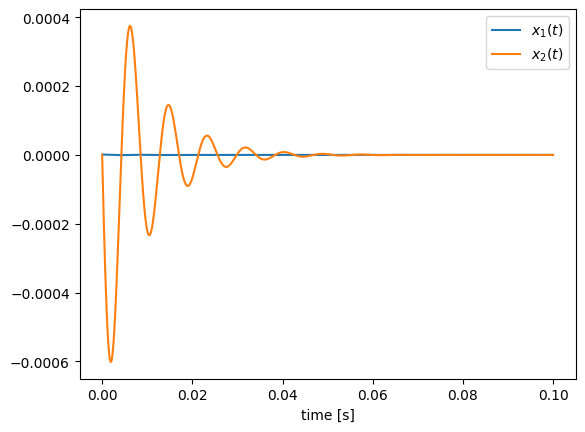

In [5]:
t, x = run_oscil([1e-6,0.0],0.1,p)
plt.plot(t,x)
plt.xlabel('time [s]')
plt.legend(['$x_1(t)$','$x_2(t)$'])

## 2.2.3: Numerical Implementation



#### Q1 : Study the sample code provided to you. What differential equation is it solving?
$$
M\ddot{\epsilon} + B\dot{\epsilon} + K\epsilon = 0
$$
#### Q2: Behavior of plots for different parameters.
This is highlighted in the next block. Since this is a second order equation, a general solution can be expressed as followed.
$$
\epsilon(t) = Ae^{\lambda_1 t} + Be^{\lambda_2 t}: \quad \lambda_1 = \frac{-B}{2M} + \frac{\sqrt{B^2-4MK}}{2M},\quad \lambda_2 = \frac{-B}{2M} - \frac{\sqrt{B^2-4MK}}{2M}  
$$ 
The nature of the solution is dependent on the values of the paramaters involved. Specifically on the $B^2-4MK$ parameter.<br>
$B^2>4MK$ is an overdamped system and hence follows the exponential. In practice it is expected to be decaying. $B^2=4MK$ is a critically damped system. $B^2<4MK$ is an oscialltory system with natural frequency $\sqrt{\frac{K}{M}}$, damping $\frac{B}{2\sqrt{MK}}$ and damped natural frequency: $\sqrt{4MK-B^2}$.

The following code is an interactive plot verifying the results.

In [6]:
import ipywidgets # Import WIdets to enable funcitoning interactive windows.

In [ ]:

def state_model(x,t,B,M,K):
    x1, x2 = x[0], x[1] # Store (eps, d(eps)/dt)
    dx1 = x2
    dx2 = (-K*x1 - B*x2) / M
    return([dx1,dx2])

def interactive_plot(M,B,K, points):
    x0=[1e-6,0]
    t = np.linspace(0,0.1,1000)
    dxdt = lambda x,t : state_model(x,t,B,M,K)
    x_t = integrate.odeint(dxdt, x0, t)
    eps = x_t[:,0]
    eps_dot = x_t[:,1]

    rand_indices = np.random.randint(0,1000, points)
    sampled_t = t[rand_indices]
    sampled_eps = eps[rand_indices]
    sampled_eps_dot = eps_dot[rand_indices]
    
    
    fig,ax = plt.subplots(2,figsize=(15,10))
    # Analaytical solution
    D = B**2 - 4*M*K # Discriminant

    lambda_1 = -B/(2*M) + np.emath.sqrt(B**2 - 4 * M * K)/(2*M) 
    lambda_2 = -B/(2*M) - np.emath.sqrt(B**2 - 4 * M * K)/(2*M)

    c,d = x0[0],x0[1]
    A,B = (lambda_2*c - d)/(lambda_2-lambda_1), (d-lambda_1*c)/(lambda_2-lambda_1)

    t = np.linspace(0,0.1,1000)
    y = A*np.exp(lambda_1*t)+B*np.exp(lambda_2*t)
    y_dot = A*lambda_1*np.exp(lambda_1*t) + B*lambda_2*np.exp(lambda_2*t)

    ax[0].scatter(sampled_t,sampled_eps,alpha=0.5,label='Points Taken from ODE solver', color='Orange')
    ax[0].plot(t,y,label='Analytical Solution')
    ax[0].set_title(f'Analytical Solution and RK4 for epsilon\nMean Squared error = {np.real(np.mean((eps-y)**2))}')
    ax[0].legend()
    ax[0].grid()

    ax[1].scatter(sampled_t,sampled_eps_dot,alpha=0.5,label='Points Taken from ODE solver randomly', color='Orange')
    ax[1].plot(t, y_dot, label='Analytical Solution')
    ax[1].set_title(f'Analytical Solution and RK4 for epsilon_dot\nMean Squared error = {np.real(np.mean((eps_dot-y_dot)**2))}')
    ax[1].legend()
    ax[1].grid()
    plt.tight_layout()

    print(B**2-4*M*K)
    plt.show()

M_base,B_base,K_base = p['M'],p['B'],p['K']
ipywidgets.interact(interactive_plot, M = (0.1*M_base, 1.8*M_base, 0.05*M_base),
                    B = (0.1*B_base, 1.8*B_base, 0.05*B_base), 
                    K = (0.1*K_base, 1.8*K_base, 0.05*K_base),
                    points = (50, 500, 10))

interactive(children=(FloatSlider(value=0.42750000000000005, description='M', max=0.81, min=0.0450000000000000…

<function __main__.interactive_plot(M, B, K, points)>

The interactive plot shows how the numerical solution matches the analytical solution. To make it easier to demonstrate that the numerical solution matches the analytical solution, I sampled random time steps from the numerical solution and showed all of them meet the expected solution. This is further verified by the mean squared error calculation. <br>

Although not asked but I find numerical methods to be particularly interesting. Although methods such as RK-4 etc help increase accuracy, they are not symplectic integrators i.e. the analytical solution would drift away from the true solution for long simulations. Methods such as verlet integrators although have a slow convergence are symplectic which means they do not drift away from the true solution. https://github.com/scipy/scipy/issues/12690 this github issue talks about this as well.

#### Q3: The following code block is the solution to question 3 in section 2.2.3 and is the implementation of the numerical method

In [8]:
def muc(x, t, p):
    x1, x2 = x[0], x[1] # Store (eps, d(eps)/dt)
    dx1 = x2 #dX/dt = ((eps_dot, eps_ddot)
    # M*eps_ddot + B*eps_dot + K*eps = P_l * (diff_x + 2*Tau*eps_dot)/(x01 + eps + tau * eps_dot)
    rhs = p['Pl'] * ((p['dx0']+2*p['tau']*x2) / (p['x01']+ x1 +p['tau']*x2))
    dx2 = 1/p['M'] * (rhs - p['B']*x2- p['K']*x1)
    return([dx1,dx2])

In [9]:
def run_lab(x0,T,p):
    t = np.linspace(0, T, 1000)
    dxdt = lambda x,t : muc(x, t, p)
    x_t = integrate.odeint(dxdt, x0, t)
    return(t,x_t)

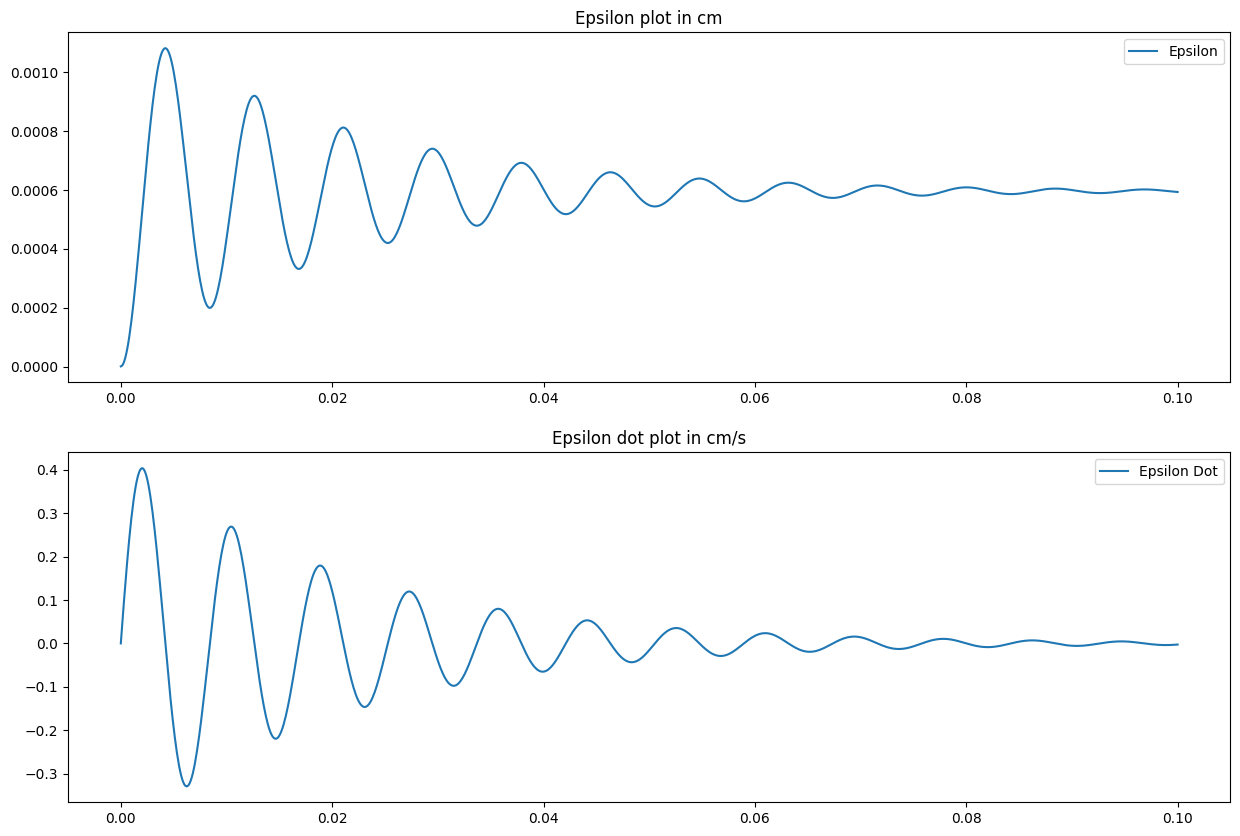

In [10]:
p = dict(Pl=1500, M=0.45, K=250000, B=100, x01=0.1, dx0=0.01, tau=0.002)
t, x = run_lab([1e-6,0.0],0.1,p)
eps, eps_dot = x[:,0], x[:,1]

fig, ax = plt.subplots(2, figsize=(15,10))

ax[0].plot(t, eps, label='Epsilon')
ax[0].set_title('Epsilon plot in cm')
ax[0].legend()

ax[1].set_title('Epsilon dot plot in cm/s')
ax[1].plot(t, eps_dot, label = 'Epsilon Dot')
ax[1].legend()
plt.show()

## 2.2.4 - Study of the mucosal model. 

#### Q1: Identify the parameters controlling the frequency of oscillation. What aspect of the response is controlled by the lung pressure?

The following code block aims to answer this question. I shall be leveraging widgets and FFTs for this. Given this system is non linear, a simple FFT may not capture the harmonic behavior and higher order peak frequencies, and may have some more uncertainities and aliasing artifacts; however, it should suffice for a rudimentary analysis for the frequency especially since the plot seems periodic. In general it is possible to numerically estimate the complete General Frequency Response Function using Volterra series/kernels but this remains outside the scope of this lab. [2] Therefore for the sake of simplicity, I have only included a FFT to study the single peak frequency that governs the periodic nature of the system.

In [11]:
def muc_vary(x,t,M,B,K,Pl,x01,dx0,tau):
    x1, x2 = x[0], x[1] # Store (eps, d(eps)/dt)
    dx1 = x2 #dX/dt = ((eps_dot, eps_ddot)
    # M*eps_ddot + B*eps_dot + K*eps = P_l * (diff_x + 2*Tau*eps_dot)/(x01 + eps + tau * eps_dot)
    rhs = Pl * ((dx0+2*tau*x2) / (x01+ x1 +tau*x2))
    dx2 = 1/M * (rhs - B*x2- K*x1)
    return([dx1,dx2])


def interact_real(M,B,K,Pl,x01,dx0,tau):
    t = np.linspace(0,0.1,1000)
    dxdt = lambda x,t : muc_vary(x, t, M,B,K,Pl,x01,dx0,tau)
    x0=[1e-6,0]
    x_t = integrate.odeint(dxdt, x0, t)
    
    fig, ax = plt.subplots(3,figsize=(23,10))
    
    ax[0].plot(t,x_t[:,0])
    ax[0].set_title('Epsilon')
    
    print(f'Final Value: {x_t[:,0][-1]}')

    ax[1].plot(t,x_t[:,1])
    ax[1].set_title('Epsilon dot')

    N = len(t)

    fft = np.fft.fft(x_t[:,0])
    freqs = np.fft.fftfreq(N, t[1]-t[0])
    ax[2].plot(freqs[freqs>0],np.abs(fft[freqs>0])**2)
    ax[2].set_title('|G(jw)|**2 of vibration')
    max_gain = np.max(np.abs(fft[freqs>0])**2)
    id = np.where(np.abs(fft[freqs>0])**2==max_gain)
    filtered_freq = freqs[freqs>0]
    max_f = filtered_freq[id]

    print(f'Gain at peak frequency: {max_gain}')
    print(f'Maximum Fequency: {max_f}')
    
    ax[2].annotate(text=f'Max_Freq: {max_f}',xy=(max_f[0], max_gain))

    plt.tight_layout()
    plt.show()


def generate_limits(a):
    return (0.05*a, 3*a, 0.05*a)

ipywidgets.interact(interact_real,
                    M=generate_limits(p['M']),
                    K=generate_limits(p['K']),
                    B=generate_limits(p['B']),
                    Pl=generate_limits(p['Pl']),
                    x01=generate_limits(p['x01']),
                    dx0=generate_limits(p['dx0']),
                    tau=generate_limits(p['tau'])
                    )

#plt.ioff()

interactive(children=(FloatSlider(value=0.675, description='M', max=1.35, min=0.022500000000000003, step=0.022…

<function __main__.interact_real(M, B, K, Pl, x01, dx0, tau)>

With the previous plots, it is possible to answer questions about what factors changes waht of the model:
However, first it is important to see the model and make judgements<br>
$$M\ddot{\epsilon}+B\dot{\epsilon}+K\epsilon = P_l\left(\frac{\Delta x_0 + 2\tau\dot{\epsilon}}{x_{01}+\epsilon+\tau\dot{\epsilon}}\right)$$

- Mass : From the plots, mass is inversely related to frequency. As the mass rises, the peak frequency decreases. This intuitively makes sense since if the mass of the vocaloid is higher, it vibrates slower.
- Damping : It controls the duration of the vibration and has no relation to the position of the maximum frequency. It does however, reduce the magnitude of the frequency plot which is as expected. Furthermore, the damping also seems to control the amplitude of the oscillations and its stablity. As damping increases, the amplitude of the time-series data decreases. For really small values of damping, the system becomes unstable. Despite the system being non-linear, the damping does seem to control the half power bandwidth of the system as well with smaller damping making it narrower. However, I really doubt the relation is as simple as outlined in the mechanics databooklet $\zeta \approx \frac{\Delta \omega}{\omega_n}$. I think over here a general frequency response may help yield a much more accurate behaviour. 
- Spring Constant : It controls the frequncy of the produced sound. Once again increasing K increases the peak frequency at the cost of decreasing the magnitude of the peak frequency and amplitude of the time-series data.
- Lung Pressure : A higher lung pressure reduces the effect of damping and increases the gain at the maximum frequency. It also increases the amplitude of the vibrations. For smaller lung pressures the solution becomes a simple SHM problem, which is particularly interesting. This suggests, that the lung pressure plays a critical role in the steady state behavior of the system. Small relative changes in lung pressure cause significant changes in the steady state value of the system. Furthermore, there must be another critical lung-pressure apart from 0 where the system is marginally stable (the system transitions from a stable system to an unstable one suggesting a critical pressure).
- $x_{01}$ : Seems to control damping but is much more sensitive as opposed to lung pressure. Smaller x01 reduces damping but makes the system more unstable.
- $\Delta x_{0}$ : Seems to contorl the final steady state value of the system (if its not unstable)
- $\tau$: Seems to control the damping of the system with higher tau decreasing the damping.

Overall: 
1. Frequency controlled by Lumped Mass and Spring Constant
2. Stablity/Damping controlled by the other factors.

After being able to study the behavior of the plots for different plots, it is clearer as to what happens in vocal production. Without sufficient external lung pressure, the amplitude and duration of the oscillations are small (of the order of miliseconds) due to the damping present within the vocal systems. However, on adding external lung pressure it is possible to increase the duration of the oscillations. Eventually if the lung pressure is large enough it completely counters the damping of the system and the oscillations can sustain themselves and help sustain voice. In other words, this external lung pressure adds energy to the system to facilate sustained oscillations and produce voice for a longer period of time. This is precisely why the system becomes unstable for smaller damping: the lung pressure is now large enough to facilate self-sustaining osciallations. This interpretation seems in line with literature. [3]<br> 

Given we now undersatand the role the lung pressure plays, we can understand that the critical pressure is going to depend on the damping, time constant, and geometry of the sytem. 
$$P_c = f(B,\tau,x_{01})$$
The next question and code helps estimate this critical pressure. 


#### Q2: Estimation of critical pressure.
As discussed in the previous discussion there must be a critical osciallation at which the system is marginally stable. To estimate it, I shall use numerical methods. 
For sustained marginally stable oscillations we require the amplitude to be constant. I shall use this to approximate the critical pressure using a grid search from 1500 to 3000 dyne/cm^2

Converged after: 13
Error in difference of successive amplitudes: 9.524631841041631e-09
Critical Pressure: 2658.14208984375


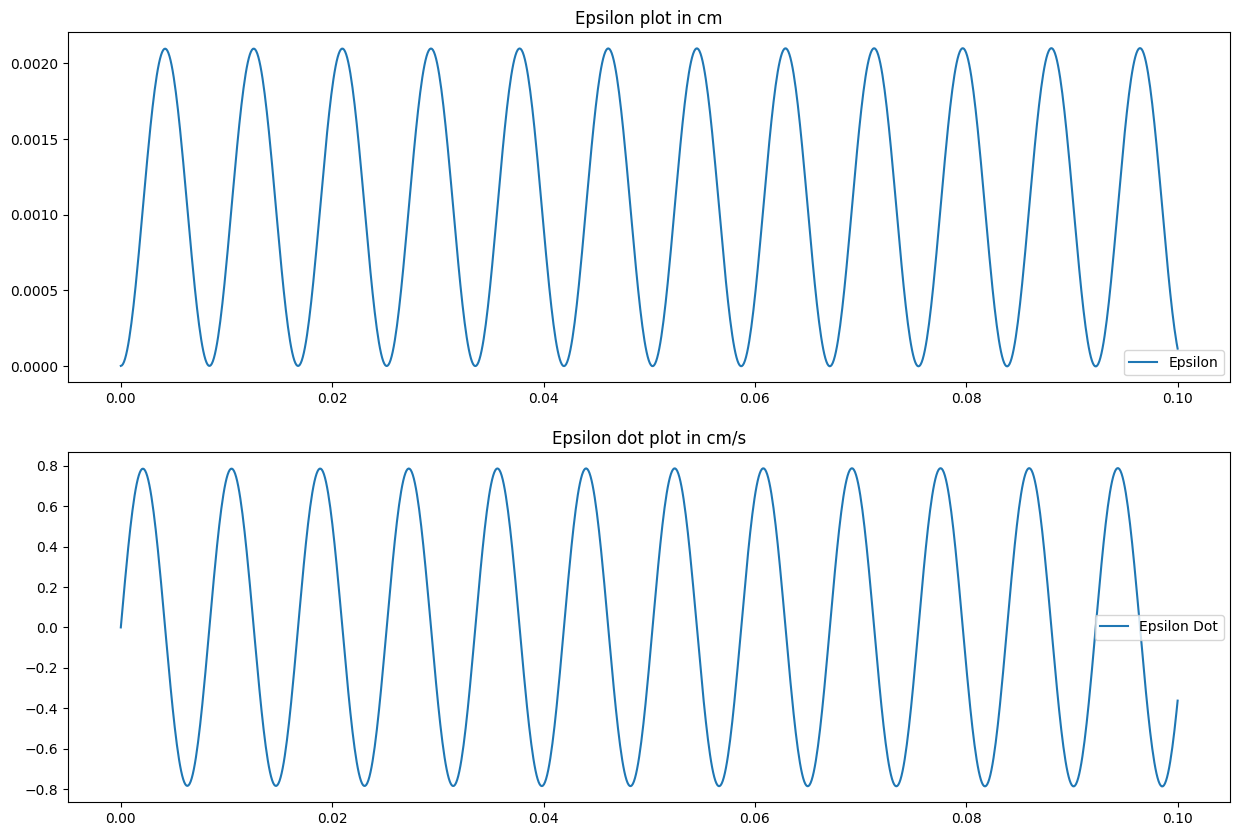

In [12]:
from scipy.signal import find_peaks
p = dict(Pl=1500, M=0.45, K=250000, B=100, x01=0.1, dx0=0.01, tau=0.002)

def obtain_diff(p):
    t,x = run_lab([1e-6,0],T=0.1,p=p)
    eps = x[:,0]
    eps_peaks_indices = find_peaks(eps)[0]
    
    first_index, second_index = eps_peaks_indices[0],eps_peaks_indices[1]
    first,second = eps[first_index],eps[second_index]
    
    diff = first - second
    return diff


def estimate_critical_pressure(p,target=0):
    Pl_start, Pl_end = 1500, 3000
    diff = float('-inf')
    max_iter = 1000
    iter_count = 0
    while np.abs(diff-target)>=1e-8 and iter_count <max_iter:
        Pl_mid = (Pl_start + Pl_end)/2
        p['Pl'] = Pl_mid
        
        diff = obtain_diff(p)
        if diff > 0:
            Pl_start = Pl_mid
        elif diff < 0:
            Pl_end = Pl_mid
        else:
            print(f'Converged with no error')
            return Pl_mid
        iter_count+=1
    
    print(f'Converged after: {iter_count}')
    print(f'Error in difference of successive amplitudes: {np.abs(diff-target)}')
    return Pl_mid, diff
        

critical_pressure, critical_diff = estimate_critical_pressure(p)
print(f'Critical Pressure: {critical_pressure}')


p['Pl'] = critical_pressure
t, x = run_lab([1e-6,0.0],0.1,p)
eps, eps_dot = x[:,0], x[:,1]

fig, ax = plt.subplots(2, figsize=(15,10))

ax[0].plot(t, eps, label='Epsilon')
ax[0].set_title('Epsilon plot in cm')
ax[0].legend()

ax[1].set_title('Epsilon dot plot in cm/s')
ax[1].plot(t, eps_dot, label = 'Epsilon Dot')
ax[1].legend()
plt.show()


This is accepted where the oscillations are self-sustained and system is marginally stable

The critical pressure of the system is at 2658 dyne/$\text{cm}^2$. To approximate the precision of the results, consider a small percent deviation in pressure, and measure the percent change in difference in successive amplitudes. Then from that estimate how much pressure change is needed for a 10% deviation in the difference betweens successive peaks.

In [13]:
deviated_pressure = critical_pressure*1.01
p['Pl'] = deviated_pressure
deviated_difference = obtain_diff(p)
relative_diff_error = np.abs((deviated_difference - critical_diff)/critical_diff)
print(f'Percent precision for 10% change in deviation: {.10*0.01/relative_diff_error*100}')

Percent precision for 10% change in deviation: 9.724616359397255e-05


Therefore, it is fair to see that the calculated pressure difference is precise upto order 1e-6. Thus we can trust our results

I did think of some other alterenative methods as well:
1. Since we expect that at the critical pressure, the system is marginally stable, it means $\epsilon = Ae^{j\omega t}$ is a valid solution to the ODE. However, doing this led to a lot of algebral.
2. Since the system would effectively have no damping, we could potentially use a FFT and find the pressure at which the half-power bandwidth is small. However, on trying this, the damping measure remained fixed at 0.1667 even though the system was marginally stable. On doing so, I realized that since the system is non-linear, traditional frequency domain analysis will not work.

#### Q3: Larger Lung Pressure

The following code shows the behavior for a large pressure. As the pressure rises, the amplitude of the system keeps increasing, (due to negative damping following arguments mentioned before). After sufficiently large pressure, the integrator crashes.

/tmp/ipykernel_9541/2687614112.py:4: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  x_t = integrate.odeint(dxdt, x0, t)


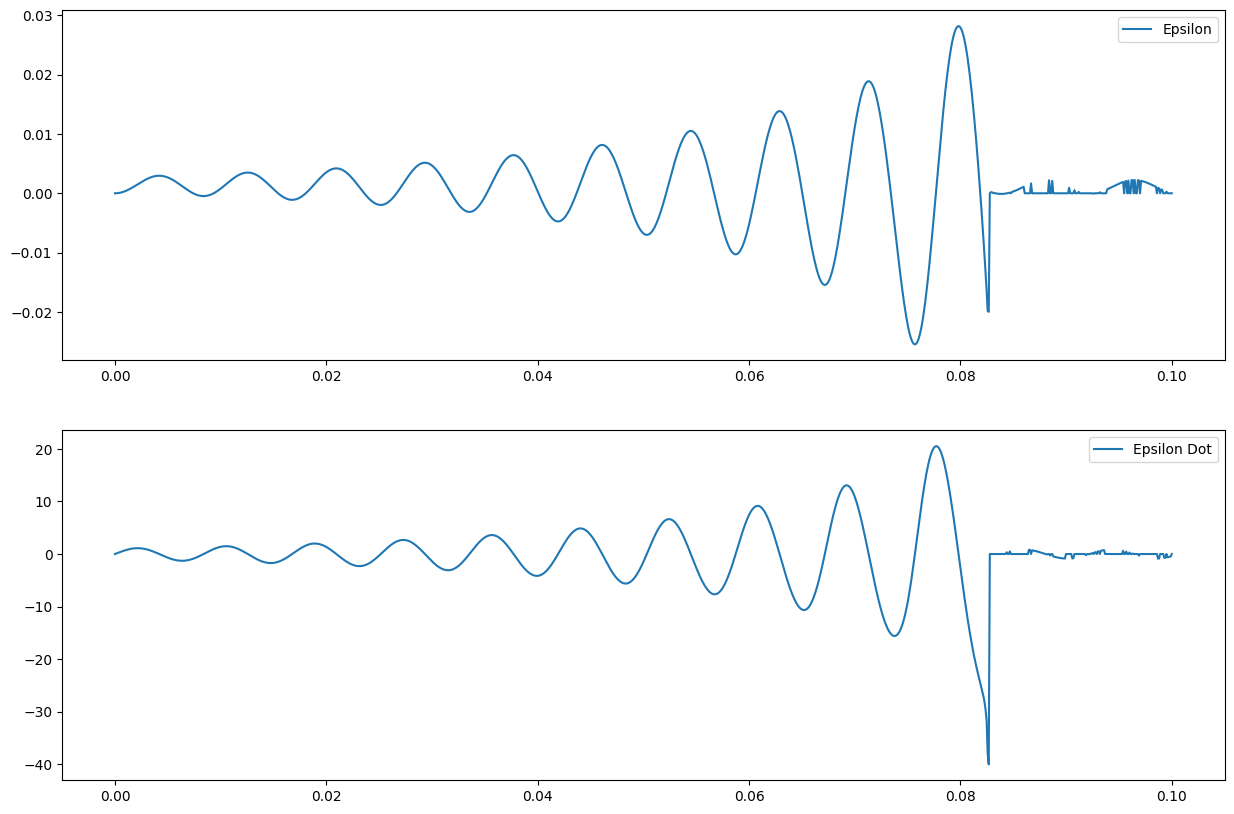

In [14]:
p = dict(Pl=3500, M=0.45, K=250000, B=100, x01=0.1, dx0=0.01, tau=0.002)

def run_lab_full_output(x0,T,p):
    t = np.linspace(0, T, 1000)
    dxdt = lambda x,t : muc(x, t, p)
    x_t = integrate.odeint(dxdt, x0, t, full_output=1)
    print(x_t)
    return(t,x_t)
t, x = run_lab([1e-6,0.0],0.1,p)
eps, eps_dot = x[:,0], x[:,1]

fig, ax = plt.subplots(2, figsize=(15,10))

ax[0].plot(t, eps, label='Epsilon')
ax[0].legend()
ax[1].plot(t, eps_dot, label = 'Epsilon Dot')
ax[1].legend()
plt.show()

As the plot above shows, the integrator eventually collapses for large pressures. Given the amplitudes of the peaks are upto large orders, it must be due to division by 0 during the integrator process. This is further evidenced from the fact that the system becomes unstable as the amplitude of the oscillations keep rising. 

Therefore, a rough guess as to how the stablity is ensured in a real system is the damping becoming sensitive to pressure. Currently, only the behavior of the vocal folds is considered and not the entire phonotic system. It is quite likely other parts of the system can help create a feedback loop to prevent the lung pressure from deviating significantly from the critical pressure. Furhtermore, a large lung pressure will also rupture the folds hence the lung pressure must be something that is controlled. A rough guess could be that the glottis will regulate the airflow and thus control the lung pressure. 

The next section is for the FTR and talks about amplitude saturation.

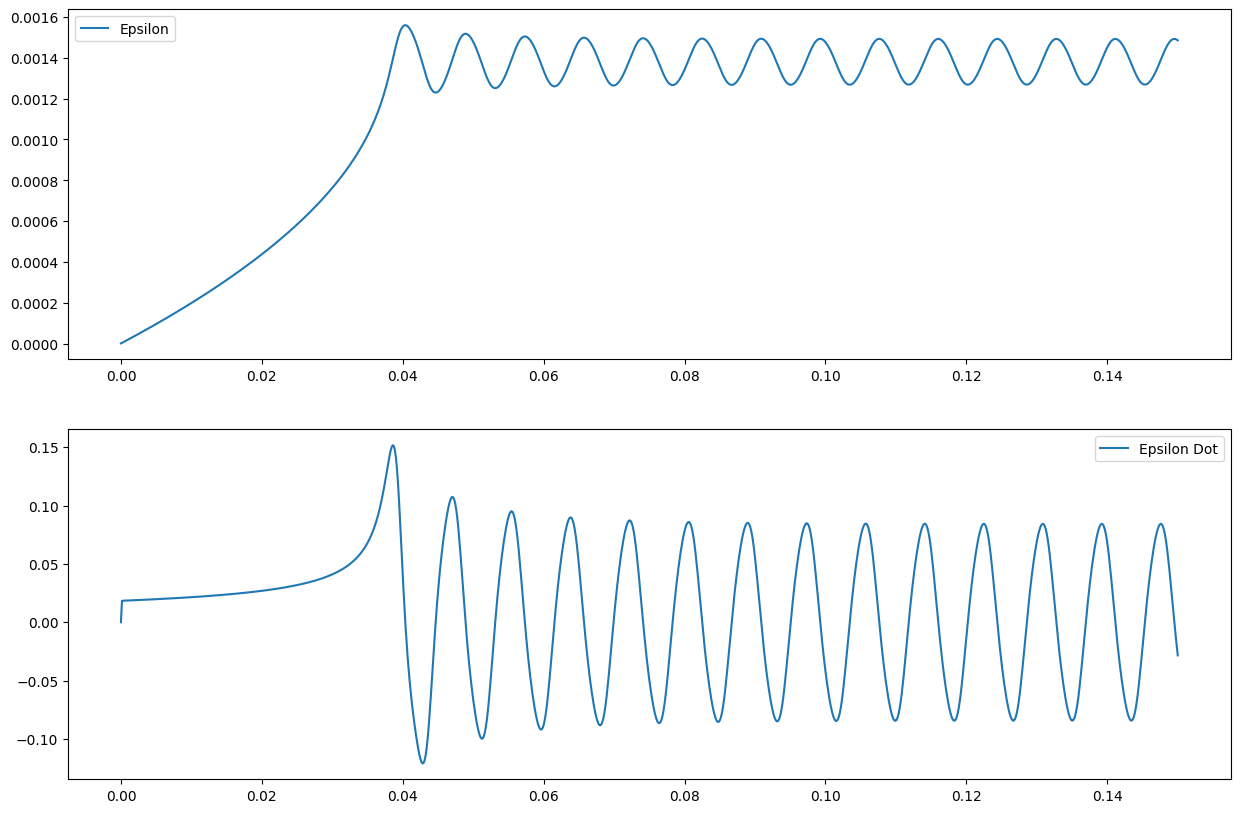

In [ ]:
def muc_sat(x, t, p):
    x1, x2 = x[0], x[1] # Store (eps, d(eps)/dt)
    dx1 = x2 #dX/dt = ((eps_dot, eps_ddot)
    # M*eps_ddot + B*eps_dot + K*eps = P_l * (diff_x + 2*Tau*eps_dot)/(x01 + eps + tau * eps_dot)
    eps_bar = (-p['K']*p['x01']+np.sqrt(p['K']**2*p['x01']**2+4*p['Pl']*p['K']*p['dx0']))/(2*p['K'])
    #print(eps_bar)
    rhs = p['Pl'] * ((p['dx0']+2*p['tau']*x2) / (p['x01']+ x1 +p['tau']*x2))
    dx2 = 1/p['M'] * (rhs - p['B']*x2*(1+p['C']*(x1-eps_bar)**2)- p['K']*x1)
    return([dx1,dx2])


def run_lab(x0,T,p):
    t = np.linspace(0, T, 1000)
    dxdt = lambda x,t : muc_sat(x, t, p)
    x_t = integrate.odeint(dxdt, x0, t)
    return(t,x_t)

p = dict(Pl=3500, M=0.45, K=250000, B=100, x01=0.1, dx0=0.01, tau=0.002, C=1000000)

t, x = run_lab([1e-6,0.0],0.15,p)
eps, eps_dot = x[:,0], x[:,1]

fig, ax = plt.subplots(2, figsize=(15,10))

ax[0].plot(t, eps, label='Epsilon')
ax[0].legend()
ax[1].plot(t, eps_dot, label = 'Epsilon Dot')
ax[1].legend()
plt.show()

## References

1 - Chao S, Song SA. Videostroboscopy. [Updated 2022 Nov 4]. In: StatPearls [Internet]. Treasure Island (FL): StatPearls Publishing; 2025 Jan-. Available from: https://www.ncbi.nlm.nih.gov/books/NBK567774/

2 - D. Stamenov, G. Abbiati, T. Sauder,
Numerical estimation of generalized frequency response functions from time series data using NARX, Mechanical Systems and Signal Processing, Volume 239, 2025, 113278,
ISSN 0888-3270, https://doi.org/10.1016/j.ymssp.2025.113278.
(https://www.sciencedirect.com/science/article/pii/S0888327025009793)

3- Titze, Ingo. (1988). The Physics of Small-Amplitude Oscillation of the Vocal Folds. The Journal of the Acoustical Society of America. 83. 1536-52. 10.1121/1.395910. 